I would like to use a very simple idea to illustrate perfect fits of using polynomials, boosting, and neural network. 

Fitting Polynomials and Calculating RMSE:
---------------------------------------
Degree  0: RMSE = 3.3017 
Degree  1: RMSE = 1.7803 
Degree  2: RMSE = 1.1053 
Degree  3: RMSE = 1.0548 
Degree  4: RMSE = 1.0500 
Degree  5: RMSE = 0.9842 
Degree  6: RMSE = 0.9475 
Degree  7: RMSE = 0.9417 
Degree  8: RMSE = 0.9152 
Degree  9: RMSE = 0.9150 
Degree 10: RMSE = 0.8086 
Degree 11: RMSE = 0.7935 
Degree 12: RMSE = 0.7750 
Degree 13: RMSE = 0.6259 
Degree 14: RMSE = 0.6248 
Degree 15: RMSE = 0.5004 
Degree 16: RMSE = 0.4139 
Degree 17: RMSE = 0.2249 
Degree 18: RMSE = 0.0774 
Degree 19: RMSE = 0.0000 **PERFECT FIT**
Degree 20: RMSE = 0.0000 **PERFECT FIT**
---------------------------------------


/Users/Kang/anaconda3/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3460: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)


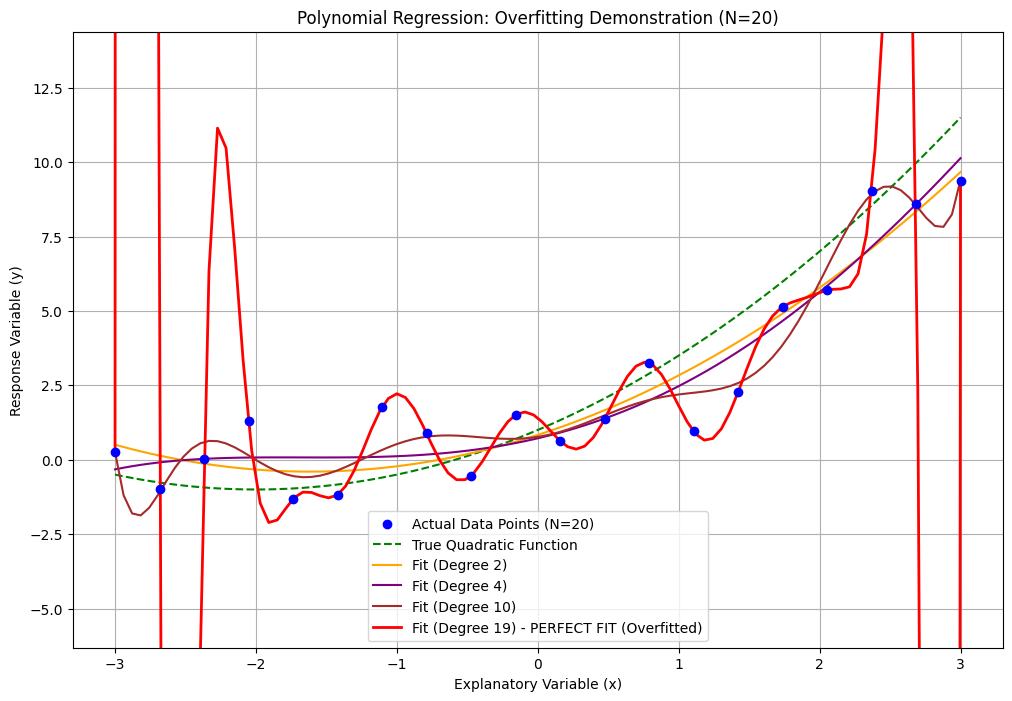

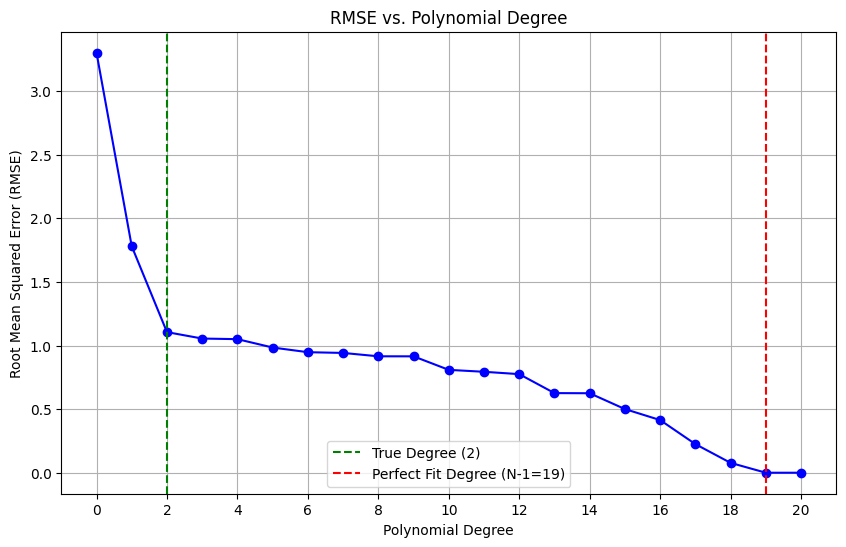

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# --- 1. Generate Data ---
np.random.seed(42) # for reproducibility
N = 20 # Number of data points

# Explanatory variable x
x = np.linspace(-3, 3, N) 

# True underlying function: y = a + bx + cx^2 + e (a=1, b=2, c=0.5)
true_a, true_b, true_c = 1, 2, 0.5
true_y = true_a + true_b * x + true_c * x**2
# Add Gaussian noise (epsilon)
noise = np.random.normal(0, 1.5, N) 
y = true_y + noise 

# --- 2. Fit Polynomials & 3. Calculate Errors ---
degrees = range(21)
rmse_list = []

print("Fitting Polynomials and Calculating RMSE:")
print("---------------------------------------")

# We fit up to degree 20 (N points means we can fit a polynomial of degree N-1 = 19 perfectly)
# Fitting a degree N polynomial will also result in a perfect fit.
for degree in degrees:
    # Use numpy.polyfit to find the coefficients
    try:
        coefficients = np.polyfit(x, y, degree)
        # Use numpy.poly1d to create the polynomial function
        polynomial = np.poly1d(coefficients)
        # Predict y values
        y_pred = polynomial(x)
        
        # Calculate RMSE
        rmse = np.sqrt(mean_squared_error(y, y_pred))
        rmse_list.append(rmse)
        
        # Check for perfect fit (RMSE close to zero)
        fit_status = ""
        if degree >= N - 1:
            fit_status = "**PERFECT FIT**"
        
        print(f"Degree {degree:2d}: RMSE = {rmse:.4f} {fit_status}")

    except Exception as e:
        # polyfit might fail for very high degrees due to numerical instability
        rmse_list.append(np.nan)
        print(f"Degree {degree:2d}: Failed ({e})")
        
print("---------------------------------------")
# --- 4. Visualize Selected Fits ---

# Create a smooth line for plotting the fitted polynomials
x_fit = np.linspace(x.min(), x.max(), 100)

plt.figure(figsize=(12, 8))
plt.scatter(x, y, color='blue', label='Actual Data Points (N=20)', zorder=5)

# Plot the true underlying function (without noise)
plt.plot(x_fit, true_a + true_b * x_fit + true_c * x_fit**2, 'g--', label='True Quadratic Function')

# Select degrees to plot:
plot_degrees = [2, 4, 10, 19] 
colors = ['orange', 'purple', 'brown', 'red']

for degree, color in zip(plot_degrees, colors):
    if degree < len(rmse_list) and not np.isnan(rmse_list[degree]):
        # Re-fit the polynomial to get the coefficients
        coefficients = np.polyfit(x, y, degree)
        polynomial = np.poly1d(coefficients)
        y_fit = polynomial(x_fit)
        
        # Plot the fitted polynomial
        if degree == 19:
            plt.plot(x_fit, y_fit, color=color, linewidth=2, linestyle='-', 
                     label=f'Fit (Degree {degree}) - PERFECT FIT (Overfitted)')
        else:
             plt.plot(x_fit, y_fit, color=color, linewidth=1.5, linestyle='-', 
                     label=f'Fit (Degree {degree})')

plt.title('Polynomial Regression: Overfitting Demonstration (N=20)')
plt.xlabel('Explanatory Variable (x)')
plt.ylabel('Response Variable (y)')
plt.ylim(min(y) - 5, max(y) + 5)
plt.legend()
plt.grid(True)
plt.show()

# Display the RMSE trend
plt.figure(figsize=(10, 6))
plt.plot(degrees, rmse_list, marker='o', linestyle='-', color='blue')
plt.title('RMSE vs. Polynomial Degree')
plt.xlabel('Polynomial Degree')
plt.ylabel('Root Mean Squared Error (RMSE)')
plt.xticks(degrees[::2])
plt.grid(True)
plt.axvline(x=2, color='g', linestyle='--', label='True Degree (2)')
plt.axvline(x=19, color='r', linestyle='--', label='Perfect Fit Degree (N-1=19)')
plt.legend()
plt.show()

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from matplotlib.animation import FuncAnimation
from IPython.display import HTML # For displaying animation in Jupyter/Colab

# --- 1. Generate Data ---
np.random.seed(42) # for reproducibility
N = 20 # Number of data points

# Explanatory variable x
x = np.linspace(-3, 3, N) 

# True underlying function: y = a + bx + cx^2 + e (a=1, b=2, c=0.5)
true_a, true_b, true_c = 1, 2, 0.5
true_y = true_a + true_b * x + true_c * x**2
# Add Gaussian noise (epsilon)
noise = np.random.normal(0, 1.5, N) 
y = true_y + noise 

# --- Prepare for Animation ---
degrees = range(20) # We'll animate from degree 0 to 19 (N-1)
x_fit = np.linspace(x.min(), x.max(), 100) # For smooth polynomial plots

# Pre-calculate all polynomial fits and RMSEs to speed up animation
all_y_fits = []
all_rmse = []

for degree in degrees:
    coefficients = np.polyfit(x, y, degree)
    polynomial = np.poly1d(coefficients)
    
    y_pred_on_data = polynomial(x) # Predictions on the original data points
    rmse = np.sqrt(mean_squared_error(y, y_pred_on_data))
    all_rmse.append(rmse)
    
    y_fit_smooth = polynomial(x_fit) # Predictions for the smooth curve
    all_y_fits.append(y_fit_smooth)

# --- Set up the plot for animation ---
fig, ax = plt.subplots(figsize=(10, 6))

# Plot actual data points once
ax.scatter(x, y, color='blue', label='Actual Data Points (N=20)', zorder=5)

# Plot the true underlying function (without noise) once, as a dashed line
ax.plot(x_fit, true_a + true_b * x_fit + true_c * x_fit**2, 'g--', 
        label='True Model (Degree 2)', linewidth=2, zorder=3)

# Initialize the plot for the current polynomial fit
line, = ax.plot([], [], 'r-', label='Polynomial Fit', linewidth=2, zorder=4)

ax.set_xlabel('Explanatory Variable (x)')
ax.set_ylabel('Response Variable (y)')
ax.set_ylim(min(y) - 5, max(y) + 5) # Set fixed y-limits for consistent viewing
ax.legend(loc='upper left')
ax.grid(True)

# --- Animation function (The Core Change) ---
def update(frame):
    current_degree = degrees[frame]
    current_y_fit = all_y_fits[frame]
    current_rmse = all_rmse[frame]

    line.set_data(x_fit, current_y_fit)
    
    # Update the title with Order and RMSE
    title_text = f'Order of Polynomial: {current_degree}'
    title_text += f' | RMSE: {current_rmse:.4f}'
    
    # Add a visual highlight for the overfitting case
    if current_degree >= N - 1:
        title_text += ' (PERFECT FIT)'

    ax.set_title(title_text)
    return line, ax.set_title('')

# Create the animation
# interval = 1000ms = 1 second per frame
ani = FuncAnimation(fig, update, frames=len(degrees), interval=1000, blit=True, repeat=False)

plt.close(fig) # Prevent the static plot from showing before animation starts

# To display in Jupyter/Colab:
HTML(ani.to_jshtml())

## Show overiftting using decision tree

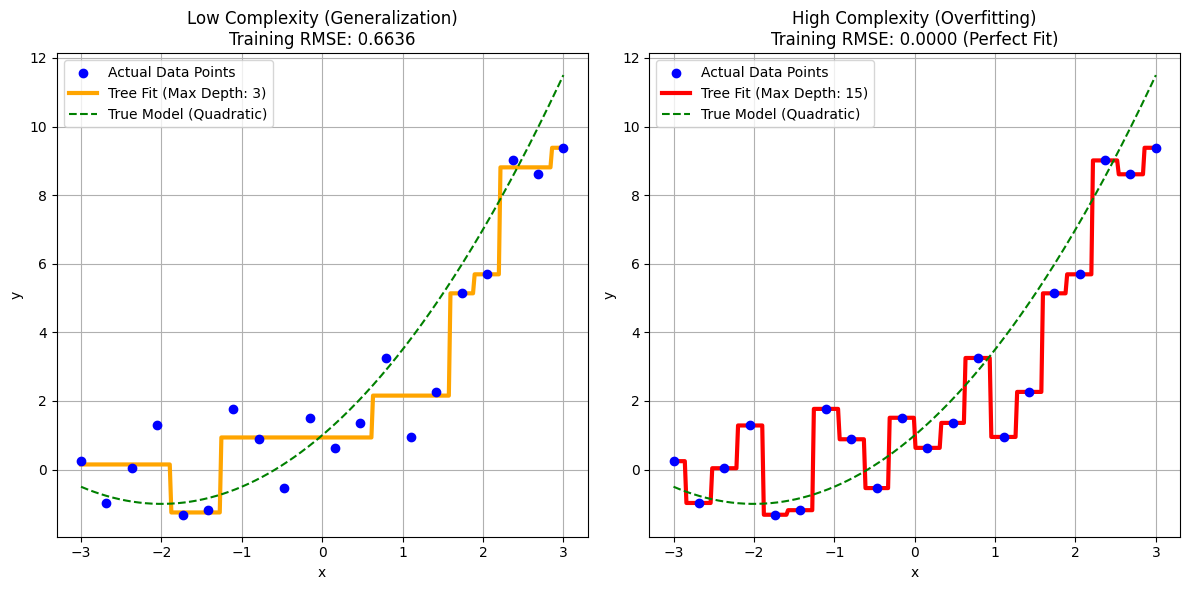

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

# --- 1. Use the Same Generated Data ---
np.random.seed(42) 
N = 20 # Number of data points
x = np.linspace(-3, 3, N).reshape(-1, 1) # Must be 2D for scikit-learn
true_a, true_b, true_c = 1, 2, 0.5
true_y = true_a + true_b * x.flatten() + true_c * x.flatten()**2
noise = np.random.normal(0, 1.5, N) 
y = true_y + noise 

# --- Prepare for Plotting ---
x_fit = np.linspace(-3, 3, 300).reshape(-1, 1) # Smooth line for predictions

# --- 2. Define Model Complexities to Compare ---
# Low Depth: Underfitting/Good Fit
MAX_DEPTH_LOW = 3 
# High Depth: Overfitting (Depth N-1 is often enough for perfect fit, 
# but setting it very high ensures the tree is fully grown)
MAX_DEPTH_HIGH = 15 

# --- 3. Fit the Decision Trees ---
# Model 1: Low Complexity
tree_low = DecisionTreeRegressor(max_depth=MAX_DEPTH_LOW, random_state=0)
tree_low.fit(x, y)
y_pred_low = tree_low.predict(x_fit)
rmse_low = np.sqrt(mean_squared_error(y, tree_low.predict(x)))

# Model 2: High Complexity (Overfitting)
tree_high = DecisionTreeRegressor(max_depth=MAX_DEPTH_HIGH, random_state=0)
tree_high.fit(x, y)
y_pred_high = tree_high.predict(x_fit)
rmse_high = np.sqrt(mean_squared_error(y, tree_high.predict(x)))

# --- 4. Visualize the Overfitting ---
plt.figure(figsize=(12, 6))

# Plot 1: Low Complexity (Good generalization)
plt.subplot(1, 2, 1)
plt.scatter(x, y, color='blue', label='Actual Data Points', zorder=5)
plt.plot(x_fit, tree_low.predict(x_fit), color='orange', linewidth=3, 
         label=f'Tree Fit (Max Depth: {MAX_DEPTH_LOW})')
plt.plot(x_fit, true_a + true_b * x_fit.flatten() + true_c * x_fit.flatten()**2, 'g--', 
         label='True Model (Quadratic)')
plt.title(f'Low Complexity (Generalization)\nTraining RMSE: {rmse_low:.4f}')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)

# Plot 2: High Complexity (Overfitting)
plt.subplot(1, 2, 2)
plt.scatter(x, y, color='blue', label='Actual Data Points', zorder=5)
plt.plot(x_fit, tree_high.predict(x_fit), color='red', linewidth=3, 
         label=f'Tree Fit (Max Depth: {MAX_DEPTH_HIGH})')
plt.plot(x_fit, true_a + true_b * x_fit.flatten() + true_c * x_fit.flatten()**2, 'g--', 
         label='True Model (Quadratic)')
plt.title(f'High Complexity (Overfitting)\nTraining RMSE: {rmse_high:.4f} (Perfect Fit)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

With animation

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from matplotlib.animation import FuncAnimation
from IPython.display import HTML # For displaying animation in Jupyter/Colab

# --- 1. Use the Same Generated Data ---
np.random.seed(42) 
N = 20 # Number of data points

# Explanatory variable x - Reshape for scikit-learn
x = np.linspace(-3, 3, N).reshape(-1, 1) 

# True underlying function: y = a + bx + cx^2 + e (a=1, b=2, c=0.5)
true_a, true_b, true_c = 1, 2, 0.5
true_y = true_a + true_b * x.flatten() + true_c * x.flatten()**2
# Add Gaussian noise (epsilon)
noise = np.random.normal(0, 1.5, N) 
y = true_y + noise 

# --- Prepare for Animation ---
# Max depths to animate. We'll go from 1 up to N (or N-1 for perfect fit)
# For N=20, a depth of 19 or 20 is usually enough for perfect fit.
max_depths = range(1, N + 1) 
x_fit = np.linspace(x.min(), x.max(), 300).reshape(-1, 1) # Smooth line for predictions

# Pre-calculate all decision tree fits and RMSEs to speed up animation
all_y_fits = []
all_rmse = []

for depth in max_depths:
    tree = DecisionTreeRegressor(max_depth=depth, random_state=0)
    tree.fit(x, y)
    
    y_pred_on_data = tree.predict(x) # Predictions on the original data points
    rmse = np.sqrt(mean_squared_error(y, y_pred_on_data))
    all_rmse.append(rmse)
    
    y_fit_smooth = tree.predict(x_fit) # Predictions for the smooth curve
    all_y_fits.append(y_fit_smooth)

# --- Set up the plot for animation ---
fig, ax = plt.subplots(figsize=(10, 6))

# Plot actual data points once
ax.scatter(x, y, color='blue', label='Actual Data Points (N=20)', zorder=5)

# Plot the true underlying function (without noise) once, as a dashed line
ax.plot(x_fit.flatten(), true_a + true_b * x_fit.flatten() + true_c * x_fit.flatten()**2, 'g--', 
        label='True Model (Quadratic)', linewidth=2, zorder=3)

# Initialize the plot for the current decision tree fit
line, = ax.plot([], [], 'r-', label='Decision Tree Fit', linewidth=2, zorder=4)

ax.set_xlabel('Explanatory Variable (x)')
ax.set_ylabel('Response Variable (y)')
ax.set_ylim(min(y) - 5, max(y) + 5) # Set fixed y-limits for consistent viewing
ax.legend(loc='upper left')
ax.grid(True)

# --- Animation function ---
def update(frame_num):
    current_depth = max_depths[frame_num]
    current_y_fit = all_y_fits[frame_num]
    current_rmse = all_rmse[frame_num]

    line.set_data(x_fit.flatten(), current_y_fit)
    
    # Update the title with Max Depth and RMSE
    title_text = f'Decision Tree Regressor | Max Depth: {current_depth}'
    title_text += f' | Training RMSE: {current_rmse:.4f}'
    
    # Highlight perfect fit
    # For decision trees, with sufficient depth, RMSE becomes 0 or very close to it.
    # Typically depth >= N will achieve this, or if each leaf gets one sample.
    if current_rmse < 0.001: # Check for near-zero RMSE for perfect fit
        title_text += ' (PERFECT FIT - Overfitting!)'

    ax.set_title(title_text)
    return line, ax.set_title('')

# Create the animation
# interval = 1000ms = 1 second per frame
ani = FuncAnimation(fig, update, frames=len(max_depths), interval=1000, blit=True, repeat=False)

plt.close(fig) # Prevent the static plot from showing before animation starts

# To display in Jupyter/Colab:
HTML(ani.to_jshtml())

Neural network

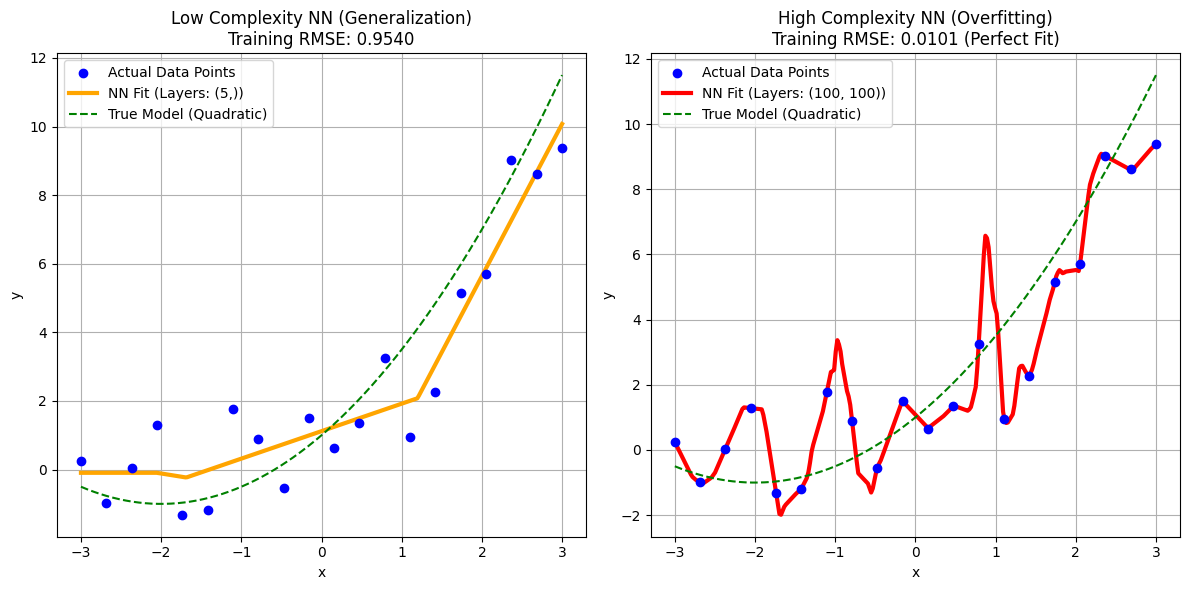

In [7]:
# --- 1. Re-run Setup and Calculations (as provided in your original script) ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# --- Data Generation and Scaling (Assuming this part ran correctly) ---
np.random.seed(42) 
N = 20
x = np.linspace(-3, 3, N).reshape(-1, 1) 
true_a, true_b, true_c = 1, 2, 0.5
true_y = true_a + true_b * x.flatten() + true_c * x.flatten()**2
noise = np.random.normal(0, 1.5, N) 
y = true_y + noise 

# Scaling setup
scaler_x = StandardScaler()
scaler_y = StandardScaler()
x_scaled = scaler_x.fit_transform(x)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()
x_fit = np.linspace(-3, 3, 300).reshape(-1, 1)
x_fit_scaled = scaler_x.transform(x_fit)

# Model definitions (Assuming these were defined as well)
LAYERS_LOW = (5,) 
LAYERS_HIGH = (100, 100) 

# NN 1: Low Complexity (Assumed to be fit)
nn_low = MLPRegressor(hidden_layer_sizes=LAYERS_LOW, activation='relu', solver='lbfgs', max_iter=10000, random_state=0)
nn_low.fit(x_scaled, y_scaled)
y_pred_low_scaled = nn_low.predict(x_fit_scaled)
y_pred_low = scaler_y.inverse_transform(y_pred_low_scaled.reshape(-1, 1)).flatten()
rmse_low = np.sqrt(mean_squared_error(y, scaler_y.inverse_transform(nn_low.predict(x_scaled).reshape(-1, 1)).flatten()))

# NN 2: High Complexity (Assumed to be fit)
nn_high = MLPRegressor(hidden_layer_sizes=LAYERS_HIGH, activation='relu', solver='lbfgs', max_iter=10000, random_state=0)
nn_high.fit(x_scaled, y_scaled)
y_pred_high_scaled = nn_high.predict(x_fit_scaled)
y_pred_high = scaler_y.inverse_transform(y_pred_high_scaled.reshape(-1, 1)).flatten()
rmse_high = np.sqrt(mean_squared_error(y, scaler_y.inverse_transform(nn_high.predict(x_scaled).reshape(-1, 1)).flatten()))

# --- FIX APPLIED HERE ---
# Calculate the true Y values for the SMOOTH X range (300 points)
# This array will have the required shape (300,)
true_y_fit = true_a + true_b * x_fit.flatten() + true_c * x_fit.flatten()**2


# --- 5. Visualize the Overfitting (Corrected Plotting) ---
plt.figure(figsize=(12, 6))

# Plot 1: Low Complexity
plt.subplot(1, 2, 1)
plt.scatter(x, y, color='blue', label='Actual Data Points', zorder=5)
plt.plot(x_fit, y_pred_low, color='orange', linewidth=3, 
         label=f'NN Fit (Layers: {LAYERS_LOW})')

# CORRECTED LINE
plt.plot(x_fit.flatten(), true_y_fit, 'g--', 
         label='True Model (Quadratic)')
# END CORRECTED LINE

plt.title(f'Low Complexity NN (Generalization)\nTraining RMSE: {rmse_low:.4f}')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)

# Plot 2: High Complexity (Overfitting)
plt.subplot(1, 2, 2)
plt.scatter(x, y, color='blue', label='Actual Data Points', zorder=5)
plt.plot(x_fit, y_pred_high, color='red', linewidth=3, 
         label=f'NN Fit (Layers: {LAYERS_HIGH})')

# CORRECTED LINE
plt.plot(x_fit.flatten(), true_y_fit, 'g--', 
         label='True Model (Quadratic)')
# END CORRECTED LINE

plt.title(f'High Complexity NN (Overfitting)\nTraining RMSE: {rmse_high:.4f} (Perfect Fit)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from matplotlib.animation import FuncAnimation
from IPython.display import HTML 

# --- 1. Generate Data ---
np.random.seed(42) 
N = 20 # Number of data points

# Explanatory variable x - Reshape for scikit-learn
x = np.linspace(-3, 3, N).reshape(-1, 1) 

# True underlying function: y = a + bx + cx^2 + e (a=1, b=2, c=0.5)
true_a, true_b, true_c = 1, 2, 0.5
true_y = true_a + true_b * x.flatten() + true_c * x.flatten()**2
noise = np.random.normal(0, 1.5, N) 
y = true_y + noise 

# --- 2. Scaling the Data ---
scaler_x = StandardScaler()
scaler_y = StandardScaler()

x_scaled = scaler_x.fit_transform(x)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

x_fit = np.linspace(-3, 3, 300).reshape(-1, 1) # Smooth line for predictions
x_fit_scaled = scaler_x.transform(x_fit)

# Calculate the true Y values for the smooth X range (300 points)
true_y_fit = true_a + true_b * x_fit.flatten() + true_c * x_fit.flatten()**2

# --- 3. Define Model Complexities to Animate ---
# We define a list of hidden layer sizes (tuples) to demonstrate increasing complexity
# Complexity increases significantly with both number of layers (depth) and neurons (width).
complexity_levels = [
    (1,),       # Very Low Capacity
    (3,),       # Low Capacity
    (5,),       # Moderate Capacity
    (10,),      # Medium Capacity
    (20,),      # High Capacity (same as N points)
    (50,),      # Very High Capacity
    (10, 10),   # Deeper and Wider
    (50, 50),   # Very High Capacity
    (100, 100)  # Maximum Capacity - guaranteed overfitting
]

# --- 4. Pre-calculate all NN fits and RMSEs ---
all_y_fits = []
all_rmse = []

for layers in complexity_levels:
    # Use lbfgs solver for better convergence on this small dataset
    nn = MLPRegressor(hidden_layer_sizes=layers, 
                      activation='relu', 
                      solver='lbfgs', 
                      max_iter=10000, 
                      random_state=0)
    nn.fit(x_scaled, y_scaled)
    
    # Calculate RMSE on training data
    y_pred_on_data_scaled = nn.predict(x_scaled)
    y_pred_on_data = scaler_y.inverse_transform(y_pred_on_data_scaled.reshape(-1, 1)).flatten()
    rmse = np.sqrt(mean_squared_error(y, y_pred_on_data))
    all_rmse.append(rmse)
    
    # Calculate predictions for the smooth plot line
    y_fit_smooth_scaled = nn.predict(x_fit_scaled)
    y_fit_smooth = scaler_y.inverse_transform(y_fit_smooth_scaled.reshape(-1, 1)).flatten()
    all_y_fits.append(y_fit_smooth)

# --- 5. Set up the plot for animation ---
fig, ax = plt.subplots(figsize=(10, 6))

# Plot actual data points once
ax.scatter(x, y, color='blue', label='Actual Data Points (N=20)', zorder=5)

# Plot the true underlying function (dashed line)
ax.plot(x_fit.flatten(), true_y_fit, 'g--', 
        label='True Model (Quadratic)', linewidth=2, zorder=3)

# Initialize the plot for the current NN fit
line, = ax.plot([], [], 'r-', label='Neural Network Fit', linewidth=2, zorder=4)

ax.set_xlabel('Explanatory Variable (x)')
ax.set_ylabel('Response Variable (y)')
ax.set_ylim(min(y) - 5, max(y) + 5) 
ax.legend(loc='upper left')
ax.grid(True)

# --- 6. Animation function ---
def update(frame_num):
    current_layers = complexity_levels[frame_num]
    current_y_fit = all_y_fits[frame_num]
    current_rmse = all_rmse[frame_num]

    line.set_data(x_fit.flatten(), current_y_fit)
    
    # Format the layer description for the title
    layer_str = 'x'.join(map(str, current_layers))
    
    # Update the title with Complexity and RMSE
    title_text = f'Neural Network Regressor | Hidden Layers: {layer_str}'
    title_text += f' | Training RMSE: {current_rmse:.4f}'
    
    # Highlight perfect fit
    if current_rmse < 0.1: # Threshold for near-perfect fit
        title_text += ' (HIGHLY OVERFITTED!)'

    ax.set_title(title_text)
    return line, ax.set_title('')

# Create the animation
ani = FuncAnimation(fig, update, frames=len(complexity_levels), interval=1000, blit=True, repeat=False)

plt.close(fig) 

# Display the animation
HTML(ani.to_jshtml())